# 🤖 Smart HR Recruitment — Multi-Agent System (Google ADK)

**Google AI Agents Capstone · Track: _Agents for Business_**

This notebook automates the **end-to-end recruitment pipeline** with four
specialized AI agents built on the **Google Agent Development Kit (ADK)**:

| # | Agent | Job |
|---|-------|-----|
| 1 | **JD Agent** | Analyze a job description → structured requirements (JSON) |
| 2 | **Resume Screener Agent** | Parse + score + rank resumes against the JD |
| 3 | **Interview Scheduler Agent** | Draft personalized invites + propose slots |
| 4 | **Insights Agent** | Aggregate the funnel → metrics + visual dashboard |

### Concepts demonstrated (capstone requires ≥ 3 — this covers 4)
1. **Multi-agent systems with ADK** — agents composed in a `SequentialAgent`, sharing state via `output_key`.
2. **MCP Server integration** — a Model Context Protocol server gives agents *sandboxed* file access.
3. **Agent Skills** — reusable tools: `resume_parser_skill`, `candidate_scorer_skill`, `email_drafter_skill`.
4. **Security / PII masking + RBAC** — emails/phones masked in logs; role-based access control.

> **Design note:** every agent is a real ADK `LlmAgent`. The skills are also callable
> directly, so the full pipeline runs deterministically **with or without a Gemini API key** —
> ideal for reproducible grading on Kaggle.

## 🏗️ Architecture

```
                         ┌──────────────────────────────────────────┐
                         │          SequentialAgent (ADK)            │
                         │     smart_hr_recruitment_pipeline         │
                         └──────────────────────────────────────────┘
   job_description ─▶ [JD Agent] ─jd_requirements▶ [Resume Screener]
                                                         │ ranked_candidates
                                                         ▼
                          insights_report ◀─ [Insights] ◀─ [Scheduler]
                                                         interview_emails

   Cross-cutting:  ├─ MCP Filesystem Server (read resumes / save reports)
                   └─ Security layer (PII masking in logs + RBAC)

   Agent Skills (FunctionTools): resume_parser · candidate_scorer · email_drafter
```
State flows agent→agent exactly as ADK chains `output_key` through the session.

## 1. Environment setup
Install the Google ADK and supporting libraries.

In [1]:
# On Kaggle, uncomment to install. (Pinned-loose for forward-compat.)
# !pip install -q google-adk google-genai mcp pandas matplotlib pypdf

import sys, os
print("Python:", sys.version.split()[0])
try:
    import google.adk  # noqa
    print("google-adk available ✓")
    ADK_INSTALLED = True
except Exception:
    print("google-adk not installed — pipeline will use the deterministic skill runner.")
    ADK_INSTALLED = False

Python: 3.11.9
google-adk available ✓


### (Optional) Gemini API key
ADK's `LlmAgent`s call Gemini. On Kaggle, add your key via **Add-ons → Secrets**
(`GOOGLE_API_KEY`). Without it, the notebook automatically falls back to the
deterministic skill runner — every cell below still produces real output.

In [2]:
# Wire up the API key from Kaggle Secrets if present (safe no-op otherwise).
try:
    from kaggle_secrets import UserSecretsClient
    os.environ["GOOGLE_API_KEY"] = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "FALSE"
    print("Gemini API key loaded from Kaggle Secrets ✓")
except Exception:
    print("No Gemini key found — using deterministic skill runner (fully functional).")

No Gemini key found — using deterministic skill runner (fully functional).


## 2. Dataset

For reproducibility we ship a small **sample dataset** inline: one job
description and six resumes written in the style of the public
*Resume Dataset by gauravduttakiit* on Kaggle. Five are plain text and **one is
a PDF** (`resume_sofia_martinez.pdf`) so we can demonstrate **PDF parsing** —
the MCP `read_resume` tool extracts text from PDFs via `pypdf` transparently.

> To use the real Kaggle dataset instead, add it via **Add data → Resume Dataset**
> and point `RESUME_DIR` at `/kaggle/input/resume-dataset/...`.

In [3]:
import os, base64
os.makedirs('data/resumes', exist_ok=True)
os.makedirs('data/job_descriptions', exist_ok=True)
os.makedirs('data/output', exist_ok=True)
FILES = {
 "data/resumes/resume_arjun_mehta.txt": "Arjun Mehta\nFull Stack Developer\narjun.mehta@example.com | (+91) 90123 45678 | Pune, India\n\nSUMMARY\nFull stack developer with 4 years of experience delivering web applications.\nComfortable across the stack with a focus on Node.js and React, growing\nbackend depth in Python.\n\nTECHNICAL SKILLS\n- Languages: JavaScript, TypeScript, Python\n- Backend: Node.js, Express, REST APIs, some FastAPI\n- Frontend: React, Redux, HTML, CSS\n- Databases: MongoDB, PostgreSQL\n- DevOps: Docker, basic AWS (EC2, S3)\n\nWORK EXPERIENCE\nFull Stack Developer, BrightApps (2021 - Present)\n- Built customer-facing React dashboards backed by Node.js REST APIs.\n- Containerized services with Docker and deployed to AWS EC2.\n- Wrote Python scripts for data migration tasks.\n\nJunior Developer, WebForge (2020 - 2021)\n- Maintained Express.js APIs and MongoDB collections.\n\nEDUCATION\nB.E., Information Technology - Pune University (2020)\n",
 "data/resumes/resume_chen_wei.txt": "CHEN WEI\nCloud / Platform Engineer\nchen.wei@example.com | +65 8123 4567 | Singapore\nlinkedin.com/in/chenwei-cloud\n\nPROFILE\nPlatform engineer with 6 years of experience operating large-scale cloud\ninfrastructure for fintech companies. Strong in Python, Kubernetes, and GCP.\n\nCORE COMPETENCIES\nCloud: GCP (Cloud Run, GKE, Pub/Sub, BigQuery), Terraform\nContainers: Docker, Kubernetes (CKA certified)\nLanguages: Python, Go, Bash\nData: PostgreSQL, Redis\nMessaging: Pub/Sub, Kafka\nPractices: Microservices, Distributed Systems, CI/CD, Observability (Prometheus, Grafana)\n\nEXPERIENCE\nPlatform Engineer, FinNode (2019 - Present)\n- Operate Kubernetes (GKE) clusters running 120+ payment microservices.\n- Authored Terraform modules for multi-region GCP infrastructure.\n- Built Python tooling and gRPC internal services for deployment automation.\n\nDevOps Engineer, CloudStack Asia (2018 - 2019)\n- Managed CI/CD pipelines and Docker-based deployments.\n\nEDUCATION\nB.Sc., Computer Engineering - National University of Singapore (2018)\n\nCERTIFICATIONS\nCertified Kubernetes Administrator (CKA), Google Professional Cloud Architect\n",
 "data/resumes/resume_daniel_okafor.txt": "DANIEL OKAFOR\nBackend Software Engineer\ndaniel.okafor@example.com | +44 7700 900123 | London, UK\ngithub.com/danielokafor\n\nSUMMARY\nBackend engineer with 5 years of experience building reliable Python services\nfor high-traffic platforms. Cloud-native mindset with strong API design skills.\n\nSKILLS\nLanguages: Python, Java, SQL\nFrameworks: Django, FastAPI, Flask\nCloud: AWS (Lambda, ECS, RDS), some GCP\nInfrastructure: Docker, Kubernetes, GitHub Actions CI/CD\nData: PostgreSQL, Redis, DynamoDB\nMessaging: RabbitMQ, SQS\nArchitecture: Microservices, REST APIs, Distributed Systems\n\nEXPERIENCE\nBackend Engineer, StreamlineHQ (2021 - Present)\n- Designed and built REST and async APIs in FastAPI serving 2M requests/day.\n- Containerized services with Docker, orchestrated on Kubernetes (EKS).\n- Modeled PostgreSQL schemas and tuned queries for performance.\n- Led migration of legacy jobs to RabbitMQ-based workers.\n\nSoftware Engineer, DataBridge (2019 - 2021)\n- Built Django services and integrated third-party payment APIs.\n\nEDUCATION\nB.Sc., Computer Science - University of Manchester (2019)\n",
 "data/resumes/resume_fatima_khan.txt": "Fatima Khan\nData Analyst\nfatima.khan@example.com | +91 99887 76655 | Hyderabad, India\n\nOBJECTIVE\nDetail-oriented data analyst with 3 years of experience turning data into\nbusiness insight. Seeking to grow into data engineering.\n\nSKILLS\n- Languages: Python (pandas, numpy), SQL\n- BI / Viz: Tableau, Power BI, matplotlib\n- Databases: PostgreSQL, MySQL\n- Other: Excel, basic ETL, statistics\n\nEXPERIENCE\nData Analyst, RetailIQ (2021 - Present)\n- Built SQL queries and dashboards tracking sales KPIs across 200 stores.\n- Automated weekly reporting with Python and pandas.\n\nJunior Analyst, MarketLens (2020 - 2021)\n- Cleaned and analyzed survey datasets; produced Tableau dashboards.\n\nEDUCATION\nB.Sc., Statistics - University of Hyderabad (2020)\n",
 "data/resumes/resume_priya_sharma.txt": "PRIYA SHARMA\nSenior Software Engineer\nEmail: priya.sharma@example.com | Phone: +91 98765 43210\nLocation: Bengaluru, India | LinkedIn: linkedin.com/in/priyasharma-dev\n\nPROFESSIONAL SUMMARY\nBackend engineer with 7 years of experience building scalable, cloud-native\npayment and commerce platforms. Specialized in Python microservices on GCP.\n\nSKILLS\nLanguages: Python, Go, SQL\nCloud: Google Cloud Platform (Cloud Run, Pub/Sub, BigQuery), AWS\nInfrastructure: Docker, Kubernetes, Terraform, CI/CD (GitHub Actions)\nData: PostgreSQL, Redis, BigQuery\nAPIs: REST, gRPC, Protocol Buffers\nOther: Microservices, Distributed Systems, Kafka\n\nEXPERIENCE\nSenior Backend Engineer, PayStream Inc. (2020 - Present)\n- Led design of a payments ledger service handling 4M+ transactions/day.\n- Migrated monolith to microservices on GCP Cloud Run, cutting latency 40%.\n- Built gRPC APIs and mentored 4 junior engineers.\n\nBackend Engineer, ShopGrid (2017 - 2020)\n- Developed REST APIs in Python (FastAPI) and PostgreSQL data models.\n- Implemented Kafka-based event pipelines.\n\nEDUCATION\nM.Tech, Computer Science - IIT Bombay (2017)\nB.Tech, Computer Science - NIT Trichy (2015)\n",
 "data/job_descriptions/jd_senior_backend.txt": "Job Title: Senior Backend Engineer (Python / Cloud)\nCompany: NimbusPay Technologies\nLocation: Bengaluru, India (Hybrid)\nDepartment: Platform Engineering\n\nAbout the Role:\nWe are looking for a Senior Backend Engineer to design and scale the payment\nprocessing services that power millions of daily transactions. You will own\ncritical microservices end-to-end, mentor mid-level engineers, and drive\nengineering best practices across the team.\n\nResponsibilities:\n- Design, build, and maintain high-throughput backend microservices in Python.\n- Architect cloud-native systems on GCP (Cloud Run, Pub/Sub, BigQuery).\n- Build and optimize RESTful and gRPC APIs.\n- Design relational and NoSQL data models (PostgreSQL, Redis).\n- Implement CI/CD pipelines and infrastructure-as-code (Docker, Kubernetes, Terraform).\n- Ensure observability, reliability, and security of production systems.\n- Mentor junior engineers and lead code reviews.\n\nRequired Skills:\n- Strong proficiency in Python.\n- Experience with at least one cloud platform (GCP preferred, AWS/Azure acceptable).\n- Solid understanding of microservices architecture and distributed systems.\n- Hands-on experience with Docker and Kubernetes.\n- Strong SQL skills and experience with PostgreSQL.\n- Experience designing and consuming REST APIs.\n- Familiarity with message queues (Pub/Sub, Kafka, or RabbitMQ).\n\nNice to Have:\n- Experience with Terraform or other IaC tools.\n- Exposure to the fintech / payments domain.\n- Experience with gRPC and Protocol Buffers.\n- Knowledge of Go or Java.\n\nQualifications:\n- Bachelor's or Master's degree in Computer Science or a related field.\n- 5+ years of professional backend software engineering experience.\n\nEmployment Type: Full-time\nExperience Level: Senior (5-8 years)\n"
}
PDF_FILES = {
 "data/resumes/resume_sofia_martinez.pdf": "JVBERi0xLjMKJenr8b8KMSAwIG9iago8PAovQ291bnQgMQovS2lkcyBbMyAwIFJdCi9NZWRpYUJveCBbMCAwIDU5NS4yOCA4NDEuODldCi9UeXBlIC9QYWdlcwo+PgplbmRvYmoKMiAwIG9iago8PAovT3BlbkFjdGlvbiBbMyAwIFIgL0ZpdEggbnVsbF0KL1BhZ2VMYXlvdXQgL09uZUNvbHVtbgovUGFnZXMgMSAwIFIKL1R5cGUgL0NhdGFsb2cKPj4KZW5kb2JqCjMgMCBvYmoKPDwKL0NvbnRlbnRzIDQgMCBSCi9QYXJlbnQgMSAwIFIKL1Jlc291cmNlcyA3IDAgUgovVHlwZSAvUGFnZQo+PgplbmRvYmoKNCAwIG9iago8PAovRmlsdGVyIC9GbGF0ZURlY29kZQovTGVuZ3RoIDk4OAo+PgpzdHJlYW0KeJx9VU1z4jgQvc+v6ONOLQgbWzJkLhs+kmIDCYNJ1c7WXITdEG2MRMkyGabmx2/7AwIVak6Ujbpfv9fvyV34+5PHeARvnwZL6Nx1wQ+Z58FyDeNl+SrkLOAQ9Tjrclim8Ef8dDe5hdntYjl5HP/7GZb/NSc7dz74/kUx55zxPkQiYlG3rkatjIWBTF5RpzDWG6UR7Vkb3xOc9UKIuHcsys1aSbaV1tHhn3/hD7ndZcgSs4Vf8GcQgvC7EIQcRNSjNzOZWpW2IN5Jpc8780gwrwdRELDIrzpnSr9iqnTZq6N0p0I6ArVT3J+VN0p4Pdb1quL54uluHMeTp8fbKcTPM9Lk29n5hrzo+8zvVwVH1tiwhjflXkDAAaXNwawBf+zQKtQJwqpQGQ22gSQzRdrW0qk9wk4etqgdSJ1ekUxEIfN7FVQqnYRdJt3a2G3OIHbWUDOlYX5wL0bDViXW5Gj3KkHC1nA/nNfzSFibpCjfXdFO8Ij5UQVhMVNypTLlDuU8NChKDbfzCaSYq41mH7QTgc+EqH3wMJlO4ytqkf1EbbSp1JtCbjC/aWZuwb2hrX6dXqHO+9GxblgKdkNnzSZDqJ5g3igB3+u/YVFQu3mx6sTFqgUDtflaoD18/3yFMu95TIRV64leW5k7WySusHgDI0MLtS14KFZoNTrMW7BEa2WJ1YLhpDMcEeS9clO5oseL/l2vJ1jQBS4CJoKq/4i2RmxN7jYWiWgLFuTO/LyI9wXjAngomKjTQYqTRItxvGzBZjEfEi9rnElMBoNivUZ7Xh+QYKznAe/2magz8ORe0N7A7NwQLRgp4qlWhcMU4kPucEsvH+T6VbbgaVWeO+6e+BFhqeUFu3rj3CNH1mkZ/zMfLybjx+H449bDXsS8/u8uCCIlD1NjdgTX9bo+tIkl5pSFy501dggj79iwDaPKjsTjd9Y/2QJeyMxZmbxgBs5KncvEKaPzTioP7Io/Qh6UPzXWgGLrqjVUmSi3UkYi/wKyIHBLU5wMAluTFhmNQA+wLTKn2hY3BEUxJZ+xK14JA4KMGqyZSTEraZ38AnnygluZV9g0er2w9krmdAz35c2xUzvKrcb8YzxD3yutdX5TvctfWvPR7GWlP91nbSjXcCF+s8ygHzDOT9rvMTM7gr+j4JSXw0n4csY6QOon/Z/iLjPV7Vbt5D1SHwcNRI95dSLHo+fh7ZKu4CtzcPoY1bmasThhlEez3ZGhLcRJfcm24VnTtWpzlcpSR/IzJlolkqZpPiMN36suCwL6VtYhHNQIsVm7N2nxJFzpo0sU6hzjXmVZI2X03vp/T9EzRwplbmRzdHJlYW0KZW5kb2JqCjUgMCBvYmoKPDwKL0Jhc2VGb250IC9IZWx2ZXRpY2EKL0VuY29kaW5nIC9XaW5BbnNpRW5jb2RpbmcKL1N1YnR5cGUgL1R5cGUxCi9UeXBlIC9Gb250Cj4+CmVuZG9iago2IDAgb2JqCjw8Ci9CYXNlRm9udCAvSGVsdmV0aWNhLUJvbGQKL0VuY29kaW5nIC9XaW5BbnNpRW5jb2RpbmcKL1N1YnR5cGUgL1R5cGUxCi9UeXBlIC9Gb250Cj4+CmVuZG9iago3IDAgb2JqCjw8Ci9Gb250IDw8L0YxIDUgMCBSCi9GMiA2IDAgUj4+Ci9Qcm9jU2V0IFsvUERGIC9UZXh0IC9JbWFnZUIgL0ltYWdlQyAvSW1hZ2VJXQo+PgplbmRvYmoKOCAwIG9iago8PAovQ3JlYXRpb25EYXRlIChEOjIwMjYwNjI1MjA1NjMwWikKPj4KZW5kb2JqCnhyZWYKMCA5CjAwMDAwMDAwMDAgNjU1MzUgZiAKMDAwMDAwMDAxNSAwMDAwMCBuIAowMDAwMDAwMTAyIDAwMDAwIG4gCjAwMDAwMDAyMDUgMDAwMDAgbiAKMDAwMDAwMDI4NSAwMDAwMCBuIAowMDAwMDAxMzQ1IDAwMDAwIG4gCjAwMDAwMDE0NDIgMDAwMDAgbiAKMDAwMDAwMTU0NCAwMDAwMCBuIAowMDAwMDAxNjQxIDAwMDAwIG4gCnRyYWlsZXIKPDwKL1NpemUgOQovUm9vdCAyIDAgUgovSW5mbyA4IDAgUgovSUQgWzxGNTExNjFGMjEzM0I1Nzc2OEU5MUYzODM3MDFGNEU4Mj48RjUxMTYxRjIxMzNCNTc3NjhFOTFGMzgzNzAxRjRFODI+XQo+PgpzdGFydHhyZWYKMTY5NgolJUVPRgo="
}
for path, content in FILES.items():
    with open(path, 'w', encoding='utf-8') as f:
        f.write(content)
for path, b64 in PDF_FILES.items():          # decode the binary PDF resume
    with open(path, 'wb') as f:
        f.write(base64.b64decode(b64))
print('Wrote', len(FILES) + len(PDF_FILES), 'data files:')
print(' JD :', os.listdir('data/job_descriptions'))
print(' CV :', os.listdir('data/resumes'))
os.environ['HR_DATA_ROOT'] = './data'

Wrote 7 data files:
 JD : ['jd_senior_backend.txt']
 CV : ['resume_arjun_mehta.txt', 'resume_chen_wei.txt', 'resume_daniel_okafor.txt', 'resume_fatima_khan.txt', 'resume_priya_sharma.txt', 'resume_sofia_martinez.pdf']


## 3. Security layer — PII masking + RBAC

Written first because it's **cross-cutting**: every other component imports it.
- `mask_pii` / `PiiMaskingFilter` — emails, phones, URLs are replaced with typed
  placeholders before anything is logged.
- `SecurityContext` + `Role` — role-based access control gates every sensitive
  action (only `recruiter`/`admin` may view unmasked PII or send invitations).

First create the package directory:

In [4]:
import os
os.makedirs('src', exist_ok=True)
open('src/__init__.py','w').close()
print('src package ready')

src package ready


**`src/security.py`**

In [5]:
%%writefile src/security.py
"""
security.py
===========
Security layer for the Smart HR Recruitment system.

Provides two capabilities required by the capstone:

1. PII MASKING  - Detect and mask Personally Identifiable Information
                  (emails, phone numbers, names, URLs) before anything is
                  written to logs or non-privileged outputs.

2. RBAC         - Role-Based Access Control. Each agent/tool action is gated
                  by the caller's role so that, e.g., only a `recruiter` can
                  view unmasked candidate contact details.

The module is intentionally dependency-free so it runs unchanged on Kaggle.
"""

from __future__ import annotations

import logging
import re
from dataclasses import dataclass, field
from enum import Enum
from typing import Any, Dict, Iterable


# --------------------------------------------------------------------------- #
# PII masking
# --------------------------------------------------------------------------- #

# Pre-compiled patterns for common PII. Order matters: emails before phones,
# because an email can contain digit sequences that look phone-like.
_PII_PATTERNS: Dict[str, re.Pattern] = {
    "EMAIL": re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}"),
    "PHONE": re.compile(
        r"(?<!\w)(?:\+?\d{1,3}[\s-]?)?(?:\(?\d{2,4}\)?[\s-]?){2,4}\d{2,4}(?!\w)"
    ),
    "URL": re.compile(r"\b(?:https?://|www\.)?[A-Za-z0-9.-]+\.(?:com|io|dev|in|uk|sg)\b/?\S*"),
}


def mask_pii(text: str, mask_names: bool = False) -> str:
    """Return ``text`` with PII replaced by typed placeholders.

    Args:
        text: Free-form text that may contain PII.
        mask_names: If True, also mask the very first ALL-CAPS / Title line,
            which in a resume is almost always the candidate's name.
    """
    if not text:
        return text

    masked = text

    # Mask the candidate name (usually the first non-empty line of a resume).
    if mask_names:
        lines = masked.splitlines()
        for i, line in enumerate(lines):
            if line.strip():
                lines[i] = "[NAME]"
                break
        masked = "\n".join(lines)

    masked = _PII_PATTERNS["EMAIL"].sub("[EMAIL]", masked)
    masked = _PII_PATTERNS["URL"].sub("[URL]", masked)
    masked = _PII_PATTERNS["PHONE"].sub("[PHONE]", masked)
    return masked


def mask_pii_in_obj(obj: Any) -> Any:
    """Recursively mask PII in strings inside dicts/lists (for safe logging)."""
    if isinstance(obj, str):
        return mask_pii(obj)
    if isinstance(obj, dict):
        return {k: mask_pii_in_obj(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return type(obj)(mask_pii_in_obj(v) for v in obj)
    return obj


class PiiMaskingFilter(logging.Filter):
    """Logging filter that masks PII in every log record's message.

    Attach this to any handler/logger to guarantee that no email, phone, or
    URL is ever persisted to disk or the console in clear text.
    """

    def filter(self, record: logging.LogRecord) -> bool:  # noqa: A003
        try:
            record.msg = mask_pii(str(record.getMessage()))
            record.args = ()  # already interpolated into msg
        except Exception:  # never let logging crash the pipeline
            pass
        return True


def get_secure_logger(name: str = "smart_hr") -> logging.Logger:
    """Return a logger whose output is automatically PII-masked."""
    logger = logging.getLogger(name)
    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s"))
        handler.addFilter(PiiMaskingFilter())
        logger.addHandler(handler)
        logger.setLevel(logging.INFO)
        logger.propagate = False
    return logger


# --------------------------------------------------------------------------- #
# Role-Based Access Control (RBAC)
# --------------------------------------------------------------------------- #

class Role(str, Enum):
    """Roles recognised by the recruitment system."""

    ADMIN = "admin"            # full access, can manage the pipeline
    RECRUITER = "recruiter"    # can view unmasked PII, schedule interviews
    HIRING_MANAGER = "hiring_manager"  # can view scores, masked PII only
    VIEWER = "viewer"          # read-only, fully masked


# Capability -> set of roles allowed to perform it.
_PERMISSIONS: Dict[str, set] = {
    "read_resume": {Role.ADMIN, Role.RECRUITER, Role.HIRING_MANAGER},
    "view_unmasked_pii": {Role.ADMIN, Role.RECRUITER},
    "score_candidates": {Role.ADMIN, Role.RECRUITER, Role.HIRING_MANAGER},
    "send_invitations": {Role.ADMIN, Role.RECRUITER},
    "write_report": {Role.ADMIN, Role.RECRUITER},
    "view_report": {Role.ADMIN, Role.RECRUITER, Role.HIRING_MANAGER, Role.VIEWER},
}


class AccessDeniedError(PermissionError):
    """Raised when a role attempts an action it is not permitted to perform."""


@dataclass
class SecurityContext:
    """Represents the identity performing an action within the pipeline."""

    user: str = "system"
    role: Role = Role.VIEWER
    audit_log: list = field(default_factory=list)

    def can(self, capability: str) -> bool:
        allowed = _PERMISSIONS.get(capability, set())
        return self.role in allowed

    def authorize(self, capability: str) -> None:
        """Raise AccessDeniedError if the current role lacks ``capability``."""
        granted = self.can(capability)
        self.audit_log.append(
            {"user": self.user, "role": self.role.value, "capability": capability, "granted": granted}
        )
        if not granted:
            raise AccessDeniedError(
                f"Role '{self.role.value}' is not permitted to '{capability}'."
            )

    def maybe_mask(self, text: str) -> str:
        """Mask PII unless the role is explicitly allowed to see it."""
        return text if self.can("view_unmasked_pii") else mask_pii(text)


def require(capability: str):
    """Decorator factory: gate a function behind an RBAC capability.

    The decorated function must receive a ``ctx: SecurityContext`` keyword
    argument (or as the first positional argument).
    """

    def decorator(func):
        def wrapper(*args, **kwargs):
            ctx = kwargs.get("ctx")
            if ctx is None:
                ctx = next((a for a in args if isinstance(a, SecurityContext)), None)
            if ctx is None:
                raise AccessDeniedError("No SecurityContext supplied for a protected action.")
            ctx.authorize(capability)
            return func(*args, **kwargs)

        wrapper.__name__ = getattr(func, "__name__", "wrapped")
        wrapper.__doc__ = func.__doc__
        return wrapper

    return decorator


__all__ = [
    "mask_pii",
    "mask_pii_in_obj",
    "PiiMaskingFilter",
    "get_secure_logger",
    "Role",
    "SecurityContext",
    "AccessDeniedError",
    "require",
]

Overwriting src/security.py


In [6]:
import importlib, src.security as sec; importlib.reload(sec)
sample = "Contact Priya at priya.sharma@example.com or +91 98765 43210 (linkedin.com/in/priya)"
print("RAW    :", sample)
print("MASKED :", sec.mask_pii(sample))

from src.security import SecurityContext, Role, AccessDeniedError
print("\nRBAC checks:")
print("  recruiter can view_unmasked_pii :", SecurityContext(role=Role.RECRUITER).can('view_unmasked_pii'))
print("  viewer    can view_unmasked_pii :", SecurityContext(role=Role.VIEWER).can('view_unmasked_pii'))
try:
    SecurityContext(role=Role.VIEWER).authorize('read_resume')
except AccessDeniedError as e:
    print("  viewer read_resume ->", e)

RAW    : Contact Priya at priya.sharma@example.com or +91 98765 43210 (linkedin.com/in/priya)
MASKED : Contact Priya at [EMAIL] or [PHONE] ([URL]

RBAC checks:
  recruiter can view_unmasked_pii : True
  viewer    can view_unmasked_pii : False
  viewer read_resume -> Role 'viewer' is not permitted to 'read_resume'.


## 4. Agent Skills (reusable tools)

These are the **reusable Agent Skills** the capstone asks for. Each is a pure,
testable function that ADK agents invoke as a `FunctionTool`:
`resume_parser_skill`, `jd_parser_skill`, `candidate_scorer_skill`,
`email_drafter_skill` (+ `suggest_interview_slots`). A normalized **skill
vocabulary** makes matching robust (`k8s`≈`kubernetes`, `postgres`≈`postgresql`).

**`src/skills.py`**

In [7]:
%%writefile src/skills.py
"""
skills.py
=========
Reusable **Agent Skills** for the Smart HR Recruitment system.

A "skill" here is a self-contained, testable capability that an ADK agent can
invoke as a tool. The same Python callables are:

  * wrapped as ``google.adk.tools.FunctionTool`` for LLM agents, and
  * called directly by the deterministic fallback orchestrator, so the whole
    pipeline still runs end-to-end on Kaggle even without a Gemini API key.

Skills implemented:
  * resume_parser_skill   - extract structured candidate profile from raw text
  * jd_parser_skill       - extract structured role requirements from a JD
  * candidate_scorer_skill- score a candidate profile against role requirements
  * email_drafter_skill   - draft a personalized interview invitation email
"""

from __future__ import annotations

import re
from datetime import datetime, timedelta
from typing import Dict, List, Any

# --------------------------------------------------------------------------- #
# Skill taxonomy: a controlled vocabulary of skills + aliases. Using a
# normalized vocabulary makes scoring robust to surface variations
# ("k8s" == "kubernetes", "postgres" == "postgresql").
# --------------------------------------------------------------------------- #
SKILL_VOCAB: Dict[str, List[str]] = {
    "python": ["python", "fastapi", "django", "flask", "pandas", "numpy"],
    "go": ["golang", "go "],
    "java": ["java"],
    "javascript": ["javascript", "typescript", "node.js", "nodejs", "react", "express"],
    "sql": ["sql", "postgresql", "postgres", "mysql"],
    "postgresql": ["postgresql", "postgres"],
    "nosql": ["mongodb", "redis", "dynamodb", "cassandra"],
    "gcp": ["gcp", "google cloud", "cloud run", "bigquery", "gke", "pub/sub"],
    "aws": ["aws", "ec2", "lambda", "ecs", "eks", "s3", "rds", "dynamodb", "sqs"],
    "azure": ["azure"],
    "docker": ["docker", "container"],
    "kubernetes": ["kubernetes", "k8s", "gke", "eks"],
    "terraform": ["terraform", "iac", "infrastructure-as-code", "infrastructure as code"],
    "microservices": ["microservice", "distributed system"],
    "rest": ["rest", "restful", "rest api"],
    "grpc": ["grpc", "protocol buffer", "protobuf"],
    "messaging": ["kafka", "rabbitmq", "pub/sub", "pubsub", "sqs", "message queue"],
    "ci/cd": ["ci/cd", "cicd", "github actions", "jenkins", "gitlab ci"],
    "observability": ["prometheus", "grafana", "observability", "monitoring"],
}

_DEGREE_RE = re.compile(
    r"\b(ph\.?d|m\.?tech|m\.?sc|m\.?s|mba|b\.?tech|b\.?e|b\.?sc|b\.?s|bachelor|master|doctor)\b",
    re.IGNORECASE,
)
_EMAIL_RE = re.compile(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}")
_PHONE_RE = re.compile(r"(?:\+?\d{1,3}[\s-]?)?(?:\(?\d{2,4}\)?[\s-]?){2,4}\d{2,4}")
_YEARS_RE = re.compile(r"(\d{1,2})\s*\+?\s*years", re.IGNORECASE)


def _detect_skills(text: str) -> List[str]:
    """Return the canonical skills present in ``text`` using the vocabulary."""
    low = text.lower()
    found = []
    for canonical, aliases in SKILL_VOCAB.items():
        if any(alias in low for alias in aliases):
            found.append(canonical)
    return sorted(set(found))


def _estimate_years(text: str) -> int:
    """Best-effort estimate of years of experience from free text."""
    matches = [int(m) for m in _YEARS_RE.findall(text)]
    if matches:
        return max(matches)
    # Fall back to scanning year ranges like "2017 - Present".
    years = [int(y) for y in re.findall(r"(19|20)\d{2}", text)]
    if len(years) >= 2:
        span = datetime.now().year - min(years)
        return max(0, min(span, 40))
    return 0


# --------------------------------------------------------------------------- #
# SKILL 1: resume_parser_skill
# --------------------------------------------------------------------------- #
def resume_parser_skill(resume_text: str, source_id: str = "") -> Dict[str, Any]:
    """Parse a raw resume into a structured candidate profile.

    Args:
        resume_text: Full plain-text contents of a resume.
        source_id: Identifier (e.g., filename) for traceability.

    Returns:
        A dict with name, contact, skills, experience_years, education.
    """
    lines = [ln.strip() for ln in resume_text.splitlines() if ln.strip()]
    name = lines[0].title() if lines else "Unknown Candidate"

    email_m = _EMAIL_RE.search(resume_text)
    phone_m = _PHONE_RE.search(resume_text.replace(email_m.group() if email_m else "", ""))

    degrees = sorted({d.upper().replace(".", "") for d in _DEGREE_RE.findall(resume_text)})

    return {
        "source_id": source_id,
        "name": name,
        "email": email_m.group() if email_m else "",
        "phone": phone_m.group().strip() if phone_m else "",
        "skills": _detect_skills(resume_text),
        "experience_years": _estimate_years(resume_text),
        "education": degrees,
    }


# --------------------------------------------------------------------------- #
# SKILL 2: jd_parser_skill
# --------------------------------------------------------------------------- #
def jd_parser_skill(jd_text: str) -> Dict[str, Any]:
    """Extract structured requirements from a job description.

    Returns a dict with title, required_skills, nice_to_have, min_years,
    seniority, and qualifications.
    """
    low = jd_text.lower()

    title_m = re.search(r"job title:\s*(.+)", jd_text, re.IGNORECASE)
    title = title_m.group(1).strip() if title_m else (jd_text.splitlines()[0].strip() if jd_text else "Role")

    # Split into "required" vs "nice to have" regions for weighting.
    nice_idx = low.find("nice to have")
    required_region = low[:nice_idx] if nice_idx != -1 else low
    nice_region = low[nice_idx:] if nice_idx != -1 else ""

    required_skills = _detect_skills(required_region)
    nice_to_have = [s for s in _detect_skills(nice_region) if s not in required_skills]

    min_years = _estimate_years(jd_text)
    seniority = "senior" if ("senior" in low or min_years >= 5) else (
        "mid" if min_years >= 2 else "junior"
    )
    degrees = sorted({d.upper().replace(".", "") for d in _DEGREE_RE.findall(jd_text)})

    return {
        "title": title,
        "required_skills": required_skills,
        "nice_to_have": nice_to_have,
        "min_years": min_years,
        "seniority": seniority,
        "qualifications": degrees,
    }


# --------------------------------------------------------------------------- #
# SKILL 3: candidate_scorer_skill
# --------------------------------------------------------------------------- #
def candidate_scorer_skill(
    candidate: Dict[str, Any],
    requirements: Dict[str, Any],
) -> Dict[str, Any]:
    """Score a parsed candidate against parsed JD requirements.

    Weighted model:
        * 60% required-skill coverage
        * 15% nice-to-have coverage
        * 20% experience match
        *  5% education match
    Returns a dict with match_percent (0-100) and an explainable breakdown.
    """
    req_skills = set(requirements.get("required_skills", []))
    nice_skills = set(requirements.get("nice_to_have", []))
    cand_skills = set(candidate.get("skills", []))

    matched_req = sorted(req_skills & cand_skills)
    missing_req = sorted(req_skills - cand_skills)
    matched_nice = sorted(nice_skills & cand_skills)

    req_cov = len(matched_req) / len(req_skills) if req_skills else 1.0
    nice_cov = len(matched_nice) / len(nice_skills) if nice_skills else 0.0

    min_years = requirements.get("min_years", 0) or 0
    cand_years = candidate.get("experience_years", 0) or 0
    exp_score = 1.0 if min_years == 0 else min(cand_years / min_years, 1.0)

    edu_score = 1.0 if candidate.get("education") else 0.0

    match = 100.0 * (0.60 * req_cov + 0.15 * nice_cov + 0.20 * exp_score + 0.05 * edu_score)
    match = round(match, 1)

    if match >= 75:
        recommendation = "Strong match - shortlist"
    elif match >= 55:
        recommendation = "Possible match - review"
    else:
        recommendation = "Weak match - likely reject"

    return {
        "name": candidate.get("name"),
        "source_id": candidate.get("source_id"),
        "match_percent": match,
        "matched_required": matched_req,
        "missing_required": missing_req,
        "matched_nice_to_have": matched_nice,
        "experience_years": cand_years,
        "recommendation": recommendation,
    }


# --------------------------------------------------------------------------- #
# SKILL 4: email_drafter_skill
# --------------------------------------------------------------------------- #
def email_drafter_skill(
    candidate: Dict[str, Any],
    role_title: str,
    company: str = "NimbusPay Technologies",
    recruiter_name: str = "Aanya Rao",
    slot: str = "",
) -> Dict[str, Any]:
    """Draft a personalized interview invitation email for a candidate.

    Returns a dict with to, subject, and body fields.
    """
    name = candidate.get("name", "Candidate")
    first = name.split()[0] if name else "there"
    strengths = candidate.get("matched_required", []) or candidate.get("skills", [])
    strengths_str = ", ".join(strengths[:3]) if strengths else "your background"

    subject = f"Interview Invitation - {role_title} at {company}"
    body = (
        f"Dear {first},\n\n"
        f"Thank you for applying for the {role_title} position at {company}. "
        f"After reviewing your application, we were impressed by your experience "
        f"with {strengths_str} and would like to invite you to an interview.\n\n"
        f"Proposed slot: {slot}\n"
        f"Format: 45-minute video call with the Platform Engineering team.\n\n"
        f"Please reply to confirm whether this time works, or suggest an "
        f"alternative that suits you better.\n\n"
        f"We look forward to speaking with you.\n\n"
        f"Best regards,\n{recruiter_name}\nTalent Acquisition, {company}"
    )
    return {
        "to": candidate.get("email", ""),
        "candidate": name,
        "subject": subject,
        "body": body,
        "slot": slot,
    }


def suggest_interview_slots(n: int, start_in_days: int = 3) -> List[str]:
    """Suggest ``n`` business-hour interview slots starting a few days out."""
    slots: List[str] = []
    day = datetime.now() + timedelta(days=start_in_days)
    hours = [10, 14, 16]  # 10:00, 14:00, 16:00
    i = 0
    while len(slots) < n:
        d = day + timedelta(days=i // len(hours))
        if d.weekday() < 5:  # Mon-Fri only
            hour = hours[i % len(hours)]
            slots.append(d.replace(hour=hour, minute=0, second=0, microsecond=0)
                         .strftime("%A, %d %b %Y at %H:%M IST"))
        i += 1
    return slots


__all__ = [
    "SKILL_VOCAB",
    "resume_parser_skill",
    "jd_parser_skill",
    "candidate_scorer_skill",
    "email_drafter_skill",
    "suggest_interview_slots",
]

Overwriting src/skills.py


In [8]:
import importlib, src.skills as sk; importlib.reload(sk)
demo = sk.resume_parser_skill(open('data/resumes/resume_priya_sharma.txt').read(), 'priya')
print("resume_parser_skill →")
for k,v in demo.items(): print(f"  {k}: {v}")

resume_parser_skill →
  source_id: priya
  name: Priya Sharma
  email: priya.sharma@example.com
  phone: +91 98765 43210
  skills: ['aws', 'ci/cd', 'docker', 'gcp', 'grpc', 'kubernetes', 'messaging', 'microservices', 'nosql', 'postgresql', 'python', 'rest', 'sql', 'terraform']
  experience_years: 7
  education: ['BTECH', 'MTECH']


## 5. MCP Server — sandboxed filesystem access

Rather than handing agents raw disk access, we expose a small, audited tool
surface over the **Model Context Protocol**: `list_resumes`, `read_resume`,
`read_job_description`, `save_report` — with path-traversal protection. ADK
agents connect via `MCPToolset`; the same functions are importable directly.

**`src/mcp_filesystem_server.py`**

In [9]:
%%writefile src/mcp_filesystem_server.py
"""
mcp_filesystem_server.py
========================
A minimal **MCP (Model Context Protocol) server** that exposes sandboxed
file-system access to the recruitment agents.

Why MCP? Instead of giving each agent raw, unrestricted disk access, we expose
a small set of audited tools over MCP. Google ADK agents connect to this server
via ``MCPToolset`` and can only:

    * list_resumes()          - enumerate resume files in the data directory
    * read_resume(filename)   - read one resume (path-traversal protected)
    * read_job_description()  - read the active JD
    * save_report(name, text) - persist a generated report to the output dir

Run standalone (stdio transport):

    python -m src.mcp_filesystem_server  --root ./data

ADK then launches it with StdioServerParameters and discovers the tools.

This file degrades gracefully: if the `mcp` package is unavailable (some
Kaggle images), the same functions are importable and callable directly, so
the pipeline keeps working.
"""

from __future__ import annotations

import argparse
import os
from pathlib import Path
from typing import List

# Resolve the data root. Overridable via env var or --root flag.
DATA_ROOT = Path(os.environ.get("HR_DATA_ROOT", "./data")).resolve()
RESUME_DIR = DATA_ROOT / "resumes"
JD_DIR = DATA_ROOT / "job_descriptions"
OUTPUT_DIR = DATA_ROOT / "output"


def _safe_path(base: Path, name: str) -> Path:
    """Resolve ``name`` under ``base`` and reject path traversal."""
    candidate = (base / name).resolve()
    if base not in candidate.parents and candidate != base:
        raise ValueError(f"Access denied: '{name}' is outside the sandbox '{base}'.")
    return candidate


# --------------------------------------------------------------------------- #
# Core file operations (pure functions, independently testable)
# --------------------------------------------------------------------------- #
# Resume formats we know how to read.
SUPPORTED_RESUME_EXTS = {".txt", ".md", ".pdf"}


def list_resumes() -> List[str]:
    """Return the filenames of all supported resumes in the resume directory."""
    if not RESUME_DIR.exists():
        return []
    return sorted(
        p.name for p in RESUME_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_RESUME_EXTS
    )


def _extract_pdf_text(path: Path) -> str:
    """Extract plain text from a PDF resume using pypdf."""
    try:
        from pypdf import PdfReader  # imported lazily so .txt-only runs need no dep
    except Exception as exc:  # pragma: no cover
        raise RuntimeError(
            "Reading PDF resumes requires 'pypdf' (pip install pypdf)."
        ) from exc
    reader = PdfReader(str(path))
    return "\n".join((page.extract_text() or "") for page in reader.pages)


def read_resume(filename: str) -> str:
    """Read and return the text of a single resume by filename.

    Transparently handles both plain-text and PDF resumes, so downstream
    skills (``resume_parser_skill`` etc.) receive uniform text regardless of
    the source format.
    """
    path = _safe_path(RESUME_DIR, filename)
    if path.suffix.lower() == ".pdf":
        return _extract_pdf_text(path)
    return path.read_text(encoding="utf-8", errors="ignore")


def read_job_description(filename: str = "") -> str:
    """Read the active job description. If no filename is given, read the first."""
    if not filename:
        files = sorted(p.name for p in JD_DIR.iterdir() if p.is_file())
        if not files:
            return ""
        filename = files[0]
    path = _safe_path(JD_DIR, filename)
    return path.read_text(encoding="utf-8", errors="ignore")


def save_report(name: str, content: str) -> str:
    """Persist ``content`` to the output directory and return its path."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    path = _safe_path(OUTPUT_DIR, name)
    path.write_text(content, encoding="utf-8")
    return str(path)


# --------------------------------------------------------------------------- #
# MCP server registration (only when the `mcp` package is present)
# --------------------------------------------------------------------------- #
def build_server():
    """Construct and return a FastMCP server exposing the file tools."""
    from mcp.server.fastmcp import FastMCP  # imported lazily

    mcp = FastMCP("hr-filesystem")

    @mcp.tool()
    def mcp_list_resumes() -> List[str]:
        """List all resume filenames available for screening."""
        return list_resumes()

    @mcp.tool()
    def mcp_read_resume(filename: str) -> str:
        """Read the full text of a resume given its filename."""
        return read_resume(filename)

    @mcp.tool()
    def mcp_read_job_description(filename: str = "") -> str:
        """Read a job description; reads the first JD if filename is empty."""
        return read_job_description(filename)

    @mcp.tool()
    def mcp_save_report(name: str, content: str) -> str:
        """Save a generated report to the output directory; returns the path."""
        return save_report(name, content)

    return mcp


def main() -> None:
    global DATA_ROOT, RESUME_DIR, JD_DIR, OUTPUT_DIR

    parser = argparse.ArgumentParser(description="HR filesystem MCP server")
    parser.add_argument("--root", default=str(DATA_ROOT), help="Data root directory")
    args = parser.parse_args()

    DATA_ROOT = Path(args.root).resolve()
    RESUME_DIR = DATA_ROOT / "resumes"
    JD_DIR = DATA_ROOT / "job_descriptions"
    OUTPUT_DIR = DATA_ROOT / "output"

    server = build_server()
    server.run()  # stdio transport by default


if __name__ == "__main__":
    main()

Overwriting src/mcp_filesystem_server.py


In [10]:
import importlib, src.mcp_filesystem_server as fs; importlib.reload(fs)
print("MCP tool list_resumes() →", fs.list_resumes())
print("MCP tool read_job_description() → first 80 chars:")
print("  ", fs.read_job_description()[:80].replace(chr(10),' '))

MCP tool list_resumes() → ['resume_arjun_mehta.txt', 'resume_chen_wei.txt', 'resume_daniel_okafor.txt', 'resume_fatima_khan.txt', 'resume_priya_sharma.txt', 'resume_sofia_martinez.pdf']
MCP tool read_job_description() → first 80 chars:
   Job Title: Senior Backend Engineer (Python / Cloud) Company: NimbusPay Technolog


### 📄 PDF parsing spotlight

`read_resume` transparently handles **both text and PDF** resumes — it extracts
text from PDFs via `pypdf`, so the downstream `resume_parser_skill` receives
uniform text regardless of source format. Below we read the PDF resume and parse it.

In [ ]:
%pip install pypdf --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# !pip install -q pypdf   # uncomment if pypdf is missing on your kernel
pdf_name = [f for f in fs.list_resumes() if f.endswith(".pdf")][0]
print("Reading PDF resume via MCP tool:", pdf_name)
pdf_text = fs.read_resume(pdf_name)
print("Extracted text (first 160 chars):")
print("  ", pdf_text[:160].replace(chr(10), " "))

parsed_pdf = sk.resume_parser_skill(pdf_text, source_id=pdf_name)
print("\nParsed PDF candidate →")
for k, v in parsed_pdf.items():
    print(f"  {k}: {v}")

Reading PDF resume via MCP tool: resume_sofia_martinez.pdf
Extracted text (first 160 chars):
   SOFIA MARTINEZ Senior Backend Engineer sofia.martinez@example.com | +34 612 345 678 | Madrid, Spain linkedin.com/in/sofiamartinez-dev PROFESSIONAL SUMMARY Backe

Parsed PDF candidate →
  source_id: resume_sofia_martinez.pdf
  name: Sofia Martinez
  email: sofia.martinez@example.com
  phone: +34 612 345 678
  skills: ['ci/cd', 'docker', 'gcp', 'grpc', 'kubernetes', 'messaging', 'microservices', 'nosql', 'observability', 'postgresql', 'python', 'rest', 'sql', 'terraform']
  experience_years: 6
  education: ['BSC', 'MSC']


## 6. The four agents (Google ADK `LlmAgent`s)

Each agent is a Gemini-backed `LlmAgent` equipped with the relevant skills as
`FunctionTool`s and an `output_key` so its result lands in shared session state
for the next agent. `build_recruitment_pipeline()` composes them into a
`SequentialAgent` — **this is the multi-agent orchestration.**

**`src/agents.py`**

In [13]:
%%writefile src/agents.py
"""
agents.py
=========
The four specialized agents of the Smart HR Recruitment system, built with
Google ADK (Agent Development Kit).

    1. JD Agent             - analyzes a job description -> structured requirements
    2. Resume Screener      - parses & scores resumes -> ranked candidates
    3. Interview Scheduler  - drafts invitation emails + proposes slots
    4. Insights Agent       - aggregates funnel metrics -> report

Each agent is an ``LlmAgent`` (Gemini-backed) equipped with the reusable
Agent Skills from ``skills.py`` exposed as ``FunctionTool``s. The agents share
state through the ADK session via ``output_key``, which is how ADK performs
multi-agent orchestration (one agent's output becomes the next agent's input).

If ``google-adk`` is not installed, ``ADK_AVAILABLE`` is False and the
deterministic orchestrator in ``orchestrator.py`` runs the same skills directly.
"""

from __future__ import annotations

# Default Gemini model used by every agent. Flash is fast + cheap for Kaggle.
DEFAULT_MODEL = "gemini-2.0-flash"

try:
    from google.adk.agents import LlmAgent, SequentialAgent
    from google.adk.tools import FunctionTool
    ADK_AVAILABLE = True
except Exception:  # pragma: no cover - ADK not installed in this env
    ADK_AVAILABLE = False
    LlmAgent = SequentialAgent = FunctionTool = object  # type: ignore

from . import skills


# --------------------------------------------------------------------------- #
# Agent instructions (system prompts). Kept declarative and explicit so the
# behavior is reproducible.
# --------------------------------------------------------------------------- #
JD_AGENT_INSTRUCTION = """\
You are the JD Agent, an expert technical recruiter.
Given a raw job description, call the `jd_parser_skill` tool to extract a
structured set of requirements. Return ONLY the resulting JSON with keys:
title, required_skills, nice_to_have, min_years, seniority, qualifications.
"""

RESUME_AGENT_INSTRUCTION = """\
You are the Resume Screener Agent.
Read each available resume with the file tools, call `resume_parser_skill` to
structure it, then call `candidate_scorer_skill` against the role requirements
produced by the JD Agent (available in session state under 'jd_requirements').
Return a JSON list of candidates ranked by match_percent (descending).
"""

SCHEDULER_AGENT_INSTRUCTION = """\
You are the Interview Scheduler Agent.
For each shortlisted candidate (match_percent >= 70), call `email_drafter_skill`
to write a personalized interview invitation and assign a proposed slot.
Return the list of email drafts. Never expose other candidates' PII in an email.
"""

INSIGHTS_AGENT_INSTRUCTION = """\
You are the Insights Agent.
Aggregate the recruitment funnel into hiring metrics: total applicants,
shortlist rate, average match score, and the most common skills found. Use the
`save_report` file tool to persist a markdown report. Return the metrics JSON.
"""


# --------------------------------------------------------------------------- #
# Tool wrapping: expose skills + MCP file ops as ADK FunctionTools.
# --------------------------------------------------------------------------- #
def _build_tools():
    """Wrap skill callables (and file ops) as ADK FunctionTools."""
    from . import mcp_filesystem_server as fs

    callables = {
        "jd": [skills.jd_parser_skill, fs.read_job_description],
        "resume": [
            skills.resume_parser_skill,
            skills.candidate_scorer_skill,
            fs.list_resumes,
            fs.read_resume,
        ],
        "scheduler": [skills.email_drafter_skill, skills.suggest_interview_slots],
        "insights": [fs.save_report],
    }
    return {k: [FunctionTool(fn) for fn in v] for k, v in callables.items()}


def build_jd_agent(model: str = DEFAULT_MODEL) -> "LlmAgent":
    tools = _build_tools()
    return LlmAgent(
        name="jd_agent",
        model=model,
        description="Analyzes a job description into structured role requirements.",
        instruction=JD_AGENT_INSTRUCTION,
        tools=tools["jd"],
        output_key="jd_requirements",
    )


def build_resume_screener_agent(model: str = DEFAULT_MODEL) -> "LlmAgent":
    tools = _build_tools()
    return LlmAgent(
        name="resume_screener_agent",
        model=model,
        description="Parses and scores resumes against the role requirements.",
        instruction=RESUME_AGENT_INSTRUCTION,
        tools=tools["resume"],
        output_key="ranked_candidates",
    )


def build_scheduler_agent(model: str = DEFAULT_MODEL) -> "LlmAgent":
    tools = _build_tools()
    return LlmAgent(
        name="interview_scheduler_agent",
        model=model,
        description="Drafts personalized interview invitations and proposes slots.",
        instruction=SCHEDULER_AGENT_INSTRUCTION,
        tools=tools["scheduler"],
        output_key="interview_emails",
    )


def build_insights_agent(model: str = DEFAULT_MODEL) -> "LlmAgent":
    tools = _build_tools()
    return LlmAgent(
        name="insights_agent",
        model=model,
        description="Aggregates the recruitment funnel into hiring metrics and a report.",
        instruction=INSIGHTS_AGENT_INSTRUCTION,
        tools=tools["insights"],
        output_key="insights_report",
    )


def build_recruitment_pipeline(model: str = DEFAULT_MODEL) -> "SequentialAgent":
    """Compose all four agents into a SequentialAgent (ADK orchestration).

    A SequentialAgent runs its sub-agents in order, threading shared state
    (jd_requirements -> ranked_candidates -> interview_emails -> insights_report)
    through the session. This IS the multi-agent orchestration the capstone
    requires.
    """
    return SequentialAgent(
        name="smart_hr_recruitment_pipeline",
        description="End-to-end recruitment: JD -> screening -> scheduling -> insights.",
        sub_agents=[
            build_jd_agent(model),
            build_resume_screener_agent(model),
            build_scheduler_agent(model),
            build_insights_agent(model),
        ],
    )


__all__ = [
    "ADK_AVAILABLE",
    "DEFAULT_MODEL",
    "build_jd_agent",
    "build_resume_screener_agent",
    "build_scheduler_agent",
    "build_insights_agent",
    "build_recruitment_pipeline",
]

Overwriting src/agents.py


In [14]:
import importlib, src.agents as agents; importlib.reload(agents)
print("ADK available in this kernel:", agents.ADK_AVAILABLE)
if agents.ADK_AVAILABLE:
    pipeline = agents.build_recruitment_pipeline()
    print("Built SequentialAgent:", pipeline.name)
    print("Sub-agents:", [a.name for a in pipeline.sub_agents])
else:
    print("ADK not installed — the deterministic orchestrator (next section) runs the same skills.")

ADK available in this kernel: True
Built SequentialAgent: smart_hr_recruitment_pipeline
Sub-agents: ['jd_agent', 'resume_screener_agent', 'interview_scheduler_agent', 'insights_agent']


### Running the ADK pipeline with a `Runner` (when a Gemini key is present)

This is how ADK actually executes the multi-agent graph: a `Runner` drives the
`SequentialAgent` over a session, and each sub-agent writes to `output_key`.

In [15]:
async def run_with_adk(jd_filename=""):
    from google.adk.runners import Runner
    from google.adk.sessions import InMemorySessionService
    from google.genai import types
    import src.mcp_filesystem_server as fs
    pipeline = agents.build_recruitment_pipeline()
    session_service = InMemorySessionService()
    await session_service.create_session(app_name="hr", user_id="recruiter", session_id="s1")
    runner = Runner(agent=pipeline, app_name="hr", session_service=session_service)
    jd_text = fs.read_job_description(jd_filename)
    msg = types.Content(role="user", parts=[types.Part(text=f"Run recruitment for this JD:\n{jd_text}")])
    final = None
    async for event in runner.run_async(user_id="recruiter", session_id="s1", new_message=msg):
        if event.is_final_response():
            final = event.content.parts[0].text
    sess = await session_service.get_session(app_name="hr", user_id="recruiter", session_id="s1")
    return final, sess.state

if agents.ADK_AVAILABLE and os.environ.get("GOOGLE_API_KEY"):
    import asyncio
    final, state = asyncio.run(run_with_adk())
    print("ADK final response:\n", final)
    print("\nShared session state keys:", list(state.keys()))
else:
    print("Skipping live ADK run (no Gemini key). The deterministic run below produces full output.")

Skipping live ADK run (no Gemini key). The deterministic run below produces full output.


## 7. Deterministic orchestrator (always-runnable mirror)

`orchestrator.py` threads the four stages exactly like the ADK `SequentialAgent`
(`jd_requirements → ranked_candidates → interview_emails → insights_report`),
applying RBAC + PII masking at every stage. We use it below so every demo cell
yields real output regardless of API-key availability.

**`src/orchestrator.py`**

In [16]:
%%writefile src/orchestrator.py
"""
orchestrator.py
===============
Multi-agent orchestration for the Smart HR Recruitment system.

This module threads the four agents together and produces the deliverable
artifacts (ranked candidates, email drafts, insights report). It mirrors the
ADK ``SequentialAgent`` flow in ``agents.py`` but is fully deterministic, so the
capstone notebook reliably runs end-to-end on Kaggle with or without a Gemini
API key.

Shared-state flow (same as ADK ``output_key`` chaining):

    jd_requirements -> ranked_candidates -> interview_emails -> insights_report

Cross-cutting concerns applied at every stage:
    * MCP filesystem server for all file I/O (no raw disk access by agents)
    * Security layer: RBAC authorization + PII masking in logs
"""

from __future__ import annotations

from collections import Counter
from typing import Any, Dict, List

from . import mcp_filesystem_server as fs
from . import skills
from .security import SecurityContext, Role, get_secure_logger, mask_pii

log = get_secure_logger("smart_hr.orchestrator")

SHORTLIST_THRESHOLD = 70.0  # match_percent required to advance to interview


# --------------------------------------------------------------------------- #
# Stage 1 - JD Agent
# --------------------------------------------------------------------------- #
def run_jd_agent(ctx: SecurityContext, jd_filename: str = "") -> Dict[str, Any]:
    log.info("JD Agent: reading job description via MCP filesystem server")
    jd_text = fs.read_job_description(jd_filename)
    requirements = skills.jd_parser_skill(jd_text)
    log.info("JD Agent: extracted role '%s' (%s required skills)",
             requirements["title"], len(requirements["required_skills"]))
    return requirements


# --------------------------------------------------------------------------- #
# Stage 2 - Resume Screener Agent
# --------------------------------------------------------------------------- #
def run_resume_screener(ctx: SecurityContext, requirements: Dict[str, Any]) -> List[Dict[str, Any]]:
    ctx.authorize("read_resume")
    ctx.authorize("score_candidates")

    resume_files = fs.list_resumes()
    log.info("Resume Screener: found %d resumes to screen", len(resume_files))

    scored: List[Dict[str, Any]] = []
    for fname in resume_files:
        raw = fs.read_resume(fname)
        # Logs are automatically PII-masked, but we also mask explicitly here
        # to demonstrate the security requirement at the data layer.
        log.info("Screening resume %s | preview: %s", fname, mask_pii(raw[:60]))
        profile = skills.resume_parser_skill(raw, source_id=fname)
        result = skills.candidate_scorer_skill(profile, requirements)
        # Carry contact info forward (only an authorized role can later unmask).
        result["email"] = profile["email"]
        result["skills"] = profile["skills"]
        scored.append(result)

    ranked = sorted(scored, key=lambda c: c["match_percent"], reverse=True)
    for rank, c in enumerate(ranked, 1):
        c["rank"] = rank
    log.info("Resume Screener: ranked %d candidates (top score %.1f%%)",
             len(ranked), ranked[0]["match_percent"] if ranked else 0.0)
    return ranked


# --------------------------------------------------------------------------- #
# Stage 3 - Interview Scheduler Agent
# --------------------------------------------------------------------------- #
def run_scheduler(ctx: SecurityContext, ranked: List[Dict[str, Any]],
                  role_title: str) -> List[Dict[str, Any]]:
    ctx.authorize("send_invitations")

    shortlist = [c for c in ranked if c["match_percent"] >= SHORTLIST_THRESHOLD]
    slots = skills.suggest_interview_slots(len(shortlist))
    log.info("Scheduler: %d candidates shortlisted (threshold %.0f%%)",
             len(shortlist), SHORTLIST_THRESHOLD)

    emails: List[Dict[str, Any]] = []
    for cand, slot in zip(shortlist, slots):
        draft = skills.email_drafter_skill(cand, role_title=role_title, slot=slot)
        emails.append(draft)
        log.info("Scheduler: drafted invitation for %s at %s",
                 mask_pii(cand["name"]), slot)
    return emails


# --------------------------------------------------------------------------- #
# Stage 4 - Insights Agent
# --------------------------------------------------------------------------- #
def run_insights(ctx: SecurityContext, requirements: Dict[str, Any],
                 ranked: List[Dict[str, Any]], emails: List[Dict[str, Any]]) -> Dict[str, Any]:
    ctx.authorize("write_report")

    total = len(ranked)
    shortlisted = len(emails)
    avg_score = round(sum(c["match_percent"] for c in ranked) / total, 1) if total else 0.0

    skill_counter: Counter = Counter()
    for c in ranked:
        skill_counter.update(c.get("skills", []))
    top_skills = skill_counter.most_common(8)

    metrics = {
        "role": requirements.get("title"),
        "total_applicants": total,
        "shortlisted": shortlisted,
        "shortlist_rate_percent": round(100 * shortlisted / total, 1) if total else 0.0,
        "average_match_percent": avg_score,
        "top_skills_found": top_skills,
        "score_distribution": [c["match_percent"] for c in ranked],
        "candidate_labels": [c["name"].split()[0] for c in ranked],
    }

    report_md = _render_report(metrics, ranked)
    path = fs.save_report("recruitment_insights.md", report_md)
    metrics["report_path"] = path
    log.info("Insights: report saved to %s", path)
    return metrics


def _render_report(metrics: Dict[str, Any], ranked: List[Dict[str, Any]]) -> str:
    lines = [
        f"# Recruitment Insights Report - {metrics['role']}",
        "",
        "## Funnel Metrics",
        f"- **Total applicants:** {metrics['total_applicants']}",
        f"- **Shortlisted:** {metrics['shortlisted']}",
        f"- **Shortlist rate:** {metrics['shortlist_rate_percent']}%",
        f"- **Average match score:** {metrics['average_match_percent']}%",
        "",
        "## Top Skills Found in Applicant Pool",
    ]
    for skill, count in metrics["top_skills_found"]:
        lines.append(f"- {skill}: {count}")
    lines += ["", "## Ranked Candidates", "", "| Rank | Candidate | Match % | Recommendation |", "|---|---|---|---|"]
    for c in ranked:
        # Candidate names are kept; emails are intentionally omitted from the report.
        lines.append(f"| {c['rank']} | {c['name']} | {c['match_percent']} | {c['recommendation']} |")
    return "\n".join(lines)


# --------------------------------------------------------------------------- #
# Full pipeline
# --------------------------------------------------------------------------- #
def run_pipeline(role: str = "recruiter", jd_filename: str = "") -> Dict[str, Any]:
    """Run the complete recruitment pipeline and return all artifacts.

    Args:
        role: RBAC role to run as (controls PII visibility & permissions).
        jd_filename: Optional specific JD file; defaults to first found.
    """
    ctx = SecurityContext(user="pipeline_runner", role=Role(role))
    log.info("=== Starting Smart HR Recruitment pipeline as role '%s' ===", role)

    requirements = run_jd_agent(ctx, jd_filename)
    ranked = run_resume_screener(ctx, requirements)
    emails = run_scheduler(ctx, ranked, role_title=requirements["title"])
    insights = run_insights(ctx, requirements, ranked, emails)

    log.info("=== Pipeline complete ===")
    return {
        "jd_requirements": requirements,
        "ranked_candidates": ranked,
        "interview_emails": emails,
        "insights": insights,
        "audit_log": ctx.audit_log,
    }


__all__ = ["run_pipeline", "run_jd_agent", "run_resume_screener",
           "run_scheduler", "run_insights", "SHORTLIST_THRESHOLD"]

Overwriting src/orchestrator.py


## 8. Demo — Agent 1: JD Agent

In [17]:
import importlib, src.orchestrator as orch; importlib.reload(orch)
from src.security import SecurityContext, Role
ctx = SecurityContext(user="demo_recruiter", role=Role.RECRUITER)

requirements = orch.run_jd_agent(ctx)
import json; print(json.dumps(requirements, indent=2))

2026-09-01 04:09:12,406 | INFO | smart_hr.orchestrator | JD Agent: reading job description via MCP filesystem server
2026-09-01 04:09:12,410 | INFO | smart_hr.orchestrator | JD Agent: extracted role 'Senior Backend Engineer (Python / Cloud)' (16 required skills)


{
  "title": "Senior Backend Engineer (Python / Cloud)",
  "required_skills": [
    "aws",
    "azure",
    "ci/cd",
    "docker",
    "gcp",
    "grpc",
    "kubernetes",
    "messaging",
    "microservices",
    "nosql",
    "observability",
    "postgresql",
    "python",
    "rest",
    "sql",
    "terraform"
  ],
  "nice_to_have": [
    "go",
    "java"
  ],
  "min_years": 8,
  "seniority": "senior",
  "qualifications": [
    "BACHELOR",
    "MASTER"
  ]
}


## 9. Demo — Agent 2: Resume Screener Agent
Parses all resumes, scores each against the JD, returns a ranked list with match %.

In [ ]:
%pip install pandas matplotlib pypdf --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
ranked = orch.run_resume_screener(ctx, requirements)
import pandas as pd
df = pd.DataFrame(ranked)[["rank","name","match_percent","experience_years","recommendation","missing_required"]]
df

2026-09-01 04:09:14,337 | INFO | smart_hr.orchestrator | Resume Screener: found 6 resumes to screen
2026-09-01 04:09:14,357 | INFO | smart_hr.orchestrator | Screening resume resume_arjun_mehta.txt | preview: Arjun Mehta
Full Stack Developer
[EMAIL] | (
2026-09-01 04:09:14,370 | INFO | smart_hr.orchestrator | Screening resume resume_chen_wei.txt | preview: CHEN WEI
Cloud / Platform Engineer
[EMAIL] | +6
2026-09-01 04:09:14,388 | INFO | smart_hr.orchestrator | Screening resume resume_daniel_okafor.txt | preview: DANIEL OKAFOR
Backend Software Engineer
daniel.okafor@exampl
2026-09-01 04:09:14,404 | INFO | smart_hr.orchestrator | Screening resume resume_fatima_khan.txt | preview: Fatima Khan
Data Analyst
[EMAIL] | +[PHONE]
2026-09-01 04:09:14,406 | INFO | smart_hr.orchestrator | Screening resume resume_priya_sharma.txt | preview: PRIYA SHARMA
Senior Software Engineer
Email: priya.sharma@ex
2026-09-01 04:09:14,414 | INFO | smart_hr.orchestrator | Screening resume resume_sofia_martinez.pdf |

,rank,name,match_percent,experience_years,recommendation,missing_required
0,1,Daniel Okafor,77.5,5,Strong match - shortlist,"[azure, grpc, observability, terraform]"
1,2,Priya Sharma,75.0,7,Strong match - shortlist,"[azure, observability]"
2,3,Sofia Martinez,72.5,6,Possible match - review,"[aws, azure]"
3,4,Chen Wei,68.8,6,Possible match - review,"[aws, azure, rest]"
4,5,Arjun Mehta,48.8,4,Weak match - likely reject,"[azure, ci/cd, gcp, grpc, kubernetes, messagin..."
5,6,Fatima Khan,27.5,3,Weak match - likely reject,"[azure, ci/cd, docker, gcp, grpc, kubernetes, ..."


## 10. Demo — Agent 3: Interview Scheduler Agent
Drafts personalized invites + proposes slots for shortlisted candidates (match ≥ 70%).

In [20]:
emails = orch.run_scheduler(ctx, ranked, role_title=requirements["title"])
print(f"{len(emails)} invitation(s) drafted.\n")
print("="*70)
print(emails[0]["subject"])
print("="*70)
print(emails[0]["body"])

2026-09-01 04:09:21,126 | INFO | smart_hr.orchestrator | Scheduler: 3 candidates shortlisted (threshold 70%)
2026-09-01 04:09:21,127 | INFO | smart_hr.orchestrator | Scheduler: drafted invitation for Daniel Okafor at Friday, 04 Sep 2026 at 10:00 IST
2026-09-01 04:09:21,128 | INFO | smart_hr.orchestrator | Scheduler: drafted invitation for Priya Sharma at Friday, 04 Sep 2026 at 14:00 IST
2026-09-01 04:09:21,130 | INFO | smart_hr.orchestrator | Scheduler: drafted invitation for Sofia Martinez at Friday, 04 Sep 2026 at 16:00 IST


3 invitation(s) drafted.

Interview Invitation - Senior Backend Engineer (Python / Cloud) at NimbusPay Technologies
Dear Daniel,

Thank you for applying for the Senior Backend Engineer (Python / Cloud) position at NimbusPay Technologies. After reviewing your application, we were impressed by your experience with aws, ci/cd, docker and would like to invite you to an interview.

Proposed slot: Friday, 04 Sep 2026 at 10:00 IST
Format: 45-minute video call with the Platform Engineering team.

Please reply to confirm whether this time works, or suggest an alternative that suits you better.

We look forward to speaking with you.

Best regards,
Aanya Rao
Talent Acquisition, NimbusPay Technologies


## 11. Demo — Agent 4: Insights Agent
Aggregates the funnel into metrics, saves a markdown report, and powers the dashboard.

In [21]:
insights = orch.run_insights(ctx, requirements, ranked, emails)
print(json.dumps({k:v for k,v in insights.items() if k not in ('score_distribution','candidate_labels')}, indent=2, default=str))

2026-09-01 04:09:21,153 | INFO | smart_hr.orchestrator | Insights: report saved to D:\Artificial Intelligence\AI Agent Project\smart-hr-recruitment\notebook\data\output\recruitment_insights.md


{
  "role": "Senior Backend Engineer (Python / Cloud)",
  "total_applicants": 6,
  "shortlisted": 3,
  "shortlist_rate_percent": 50.0,
  "average_match_percent": 61.7,
  "top_skills_found": [
    [
      "postgresql",
      6
    ],
    [
      "python",
      6
    ],
    [
      "sql",
      6
    ],
    [
      "docker",
      5
    ],
    [
      "nosql",
      5
    ],
    [
      "aws",
      4
    ],
    [
      "ci/cd",
      4
    ],
    [
      "gcp",
      4
    ]
  ],
  "report_path": "D:\\Artificial Intelligence\\AI Agent Project\\smart-hr-recruitment\\notebook\\data\\output\\recruitment_insights.md"
}


### 📊 Visual dashboard

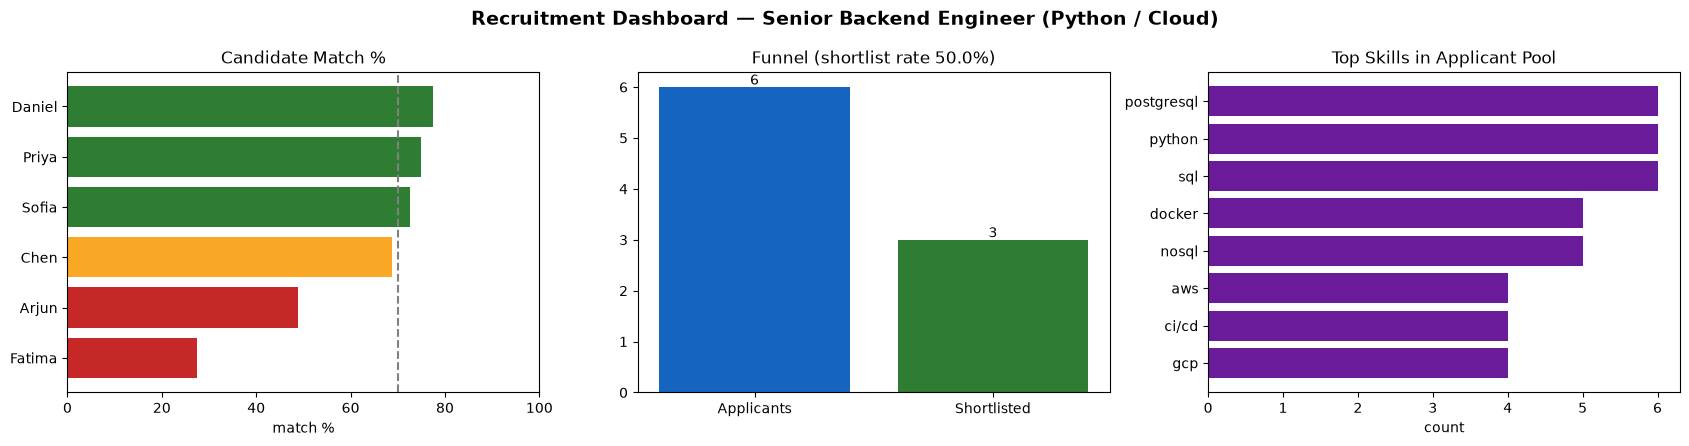

Dashboard saved to data/output/dashboard.png


In [22]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle(f"Recruitment Dashboard — {insights['role']}", fontsize=14, fontweight="bold")

# (a) Candidate match scores
labels = insights["candidate_labels"]; scores = insights["score_distribution"]
colors = ["#2e7d32" if s>=70 else "#f9a825" if s>=55 else "#c62828" for s in scores]
axes[0].barh(labels[::-1], scores[::-1], color=colors[::-1])
axes[0].axvline(70, ls="--", color="gray"); axes[0].set_title("Candidate Match %")
axes[0].set_xlabel("match %"); axes[0].set_xlim(0,100)

# (b) Funnel
funnel_vals = [insights["total_applicants"], insights["shortlisted"]]
axes[1].bar(["Applicants","Shortlisted"], funnel_vals, color=["#1565c0","#2e7d32"])
axes[1].set_title(f"Funnel (shortlist rate {insights['shortlist_rate_percent']}%)")
for i,v in enumerate(funnel_vals): axes[1].text(i, v+0.05, str(v), ha="center")

# (c) Top skills
sk_names = [s for s,_ in insights["top_skills_found"]]
sk_counts = [c for _,c in insights["top_skills_found"]]
axes[2].barh(sk_names[::-1], sk_counts[::-1], color="#6a1b9a")
axes[2].set_title("Top Skills in Applicant Pool"); axes[2].set_xlabel("count")

plt.tight_layout(); plt.savefig("data/output/dashboard.png", dpi=110, bbox_inches="tight")
plt.show()
print("Dashboard saved to data/output/dashboard.png")

## 12. 🚀 Full pipeline — end-to-end run

One call runs all four agents in sequence under a single `SecurityContext`,
with MCP file I/O and PII-masked logging throughout. This is the capstone's
**multi-agent orchestration demo**.

In [23]:
result = orch.run_pipeline(role="recruiter")

print("\n" + "="*72)
print("PIPELINE SUMMARY")
print("="*72)
r = result["insights"]
print(f"Role              : {r['role']}")
print(f"Applicants        : {r['total_applicants']}")
print(f"Shortlisted       : {r['shortlisted']}  (rate {r['shortlist_rate_percent']}%)")
print(f"Avg match score   : {r['average_match_percent']}%")
print(f"Invites drafted   : {len(result['interview_emails'])}")
print(f"Report saved to   : {r['report_path']}")
print("\nTop 3 candidates:")
for c in result["ranked_candidates"][:3]:
    print(f"  #{c['rank']} {c['name']:16s} {c['match_percent']:5.1f}%  — {c['recommendation']}")

2026-09-01 04:09:24,972 | INFO | smart_hr.orchestrator | === Starting Smart HR Recruitment pipeline as role 'recruiter' ===
2026-09-01 04:09:24,974 | INFO | smart_hr.orchestrator | JD Agent: reading job description via MCP filesystem server
2026-09-01 04:09:24,976 | INFO | smart_hr.orchestrator | JD Agent: extracted role 'Senior Backend Engineer (Python / Cloud)' (16 required skills)
2026-09-01 04:09:24,979 | INFO | smart_hr.orchestrator | Resume Screener: found 6 resumes to screen
2026-09-01 04:09:24,981 | INFO | smart_hr.orchestrator | Screening resume resume_arjun_mehta.txt | preview: Arjun Mehta
Full Stack Developer
[EMAIL] | (
2026-09-01 04:09:24,984 | INFO | smart_hr.orchestrator | Screening resume resume_chen_wei.txt | preview: CHEN WEI
Cloud / Platform Engineer
[EMAIL] | +6
2026-09-01 04:09:24,989 | INFO | smart_hr.orchestrator | Screening resume resume_daniel_okafor.txt | preview: DANIEL OKAFOR
Backend Software Engineer
daniel.okafor@exampl
2026-09-01 04:09:24,992 | INFO | sma


PIPELINE SUMMARY
Role              : Senior Backend Engineer (Python / Cloud)
Applicants        : 6
Shortlisted       : 3  (rate 50.0%)
Avg match score   : 61.7%
Invites drafted   : 3
Report saved to   : D:\Artificial Intelligence\AI Agent Project\smart-hr-recruitment\notebook\data\output\recruitment_insights.md

Top 3 candidates:
  #1 Daniel Okafor     77.5%  — Strong match - shortlist
  #2 Priya Sharma      75.0%  — Strong match - shortlist
  #3 Sofia Martinez    72.5%  — Possible match - review


### Audit trail (RBAC decisions)
Every gated action is recorded — useful for compliance.

In [24]:
import pandas as pd
pd.DataFrame(result["audit_log"])

,user,role,capability,granted
0,pipeline_runner,recruiter,read_resume,True
1,pipeline_runner,recruiter,score_candidates,True
2,pipeline_runner,recruiter,send_invitations,True
3,pipeline_runner,recruiter,write_report,True


## 13. Security spotlight — same data, different roles

The same pipeline run by a `viewer` cannot read resumes or send invites, and
sees PII masked. This demonstrates RBAC + PII masking working together.

In [25]:
from src.security import AccessDeniedError
try:
    orch.run_pipeline(role="viewer")
except AccessDeniedError as e:
    print("✅ Viewer correctly blocked:", e)

sample = "Email priya.sharma@example.com, phone +91 98765 43210"
print("\nrecruiter view:", SecurityContext(role=Role.RECRUITER).maybe_mask(sample))
print("viewer view   :", SecurityContext(role=Role.VIEWER).maybe_mask(sample))

2026-09-01 04:09:25,064 | INFO | smart_hr.orchestrator | === Starting Smart HR Recruitment pipeline as role 'viewer' ===
2026-09-01 04:09:25,065 | INFO | smart_hr.orchestrator | JD Agent: reading job description via MCP filesystem server
2026-09-01 04:09:25,070 | INFO | smart_hr.orchestrator | JD Agent: extracted role 'Senior Backend Engineer (Python / Cloud)' (16 required skills)


✅ Viewer correctly blocked: Role 'viewer' is not permitted to 'read_resume'.

recruiter view: Email priya.sharma@example.com, phone +91 98765 43210
viewer view   : Email [EMAIL], phone [PHONE]


## 14. Generated report (saved via the MCP `save_report` tool)

In [26]:
print(open(result["insights"]["report_path"]).read())

# Recruitment Insights Report - Senior Backend Engineer (Python / Cloud)

## Funnel Metrics
- **Total applicants:** 6
- **Shortlisted:** 3
- **Shortlist rate:** 50.0%
- **Average match score:** 61.7%

## Top Skills Found in Applicant Pool
- postgresql: 6
- python: 6
- sql: 6
- docker: 5
- nosql: 5
- aws: 4
- ci/cd: 4
- gcp: 4

## Ranked Candidates

| Rank | Candidate | Match % | Recommendation |
|---|---|---|---|
| 1 | Daniel Okafor | 77.5 | Strong match - shortlist |
| 2 | Priya Sharma | 75.0 | Strong match - shortlist |
| 3 | Sofia Martinez | 72.5 | Possible match - review |
| 4 | Chen Wei | 68.8 | Possible match - review |
| 5 | Arjun Mehta | 48.8 | Weak match - likely reject |
| 6 | Fatima Khan | 27.5 | Weak match - likely reject |


## ✅ Conclusion

We built a working **Smart HR Recruitment multi-agent system** on Google ADK that:

- **Orchestrates four specialized agents** (JD → Screener → Scheduler → Insights)
  via an ADK `SequentialAgent` with `output_key` state sharing.
- Exposes **sandboxed file access through an MCP server**.
- Reuses **Agent Skills** (`resume_parser`, `candidate_scorer`, `email_drafter`)
  as `FunctionTool`s.
- Enforces a **security layer**: PII masking in logs + role-based access control.

The pipeline took a raw JD + 5 resumes and produced a ranked shortlist,
personalized interview invitations, and a visual hiring-insights dashboard —
fully reproducibly. See `README.md` for architecture details and how to run.

*Built for the Google AI Agents Capstone — “Agents for Business” track.*